## Data splits: ROBOFLOW DATA SET ##
Split the data into training, validation and testing data

In [1]:
import os
import sys
import glob
import random
import logging
import json
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import cv2

import albumentations as alb

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

%load_ext autoreload
%autoreload 2
import computervision
from computervision.dentex import Dentex
from computervision.imageproc import ImageData, is_image, plot_boxes, clipxywh
from computervision.transformations import AugmentationTransform, DETRansform

# Print version info
print(f'Package version: {computervision.__version__}')
print(f'Python version:  {sys.version}')

Package version: v0.0.2
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [2]:
data_dir = os.environ.get('DATA')
print(f'data_dir: {data_dir}')
image_dir = os.path.join(data_dir, 'dataset_object_roboflow_240930')
print(f'data_dir: {data_dir}')

parquet_file_name = 'roboflow_240930.parquet'
parquet_file = os.path.join(image_dir, parquet_file_name)

# Create a new file name for the output data frame
clipped_file_name = f'{os.path.splitext(parquet_file_name)[0]}_clipped.parquet'
clipped_file = os.path.join(image_dir, clipped_file_name)
dset_file_name = f'{os.path.splitext(parquet_file_name)[0]}_dset.parquet'
dset_file = os.path.join(image_dir, dset_file_name)

try:
    df = pd.read_parquet(parquet_file)
except Exception as e:
    print(f'ERROR: Could not load file: \n {e}')
    print('Make sure to run the first notebook which downloads the data.')

file_col = 'multi_file'
bbox_col = 'bbox'
pos_col = 'pos'
disease_col = 'disease'

# Let's get the data with the position information
print(f'Filtering emtpy bbox rows BEFORE: {df.shape[0]}')
df = df.loc[~df[bbox_col].isnull()]
print(f'Filtering emtpy bbox rows AFTER: {df.shape[0]}')
display(df.head(2))

# Check the images
file_name_list = sorted(list(df[file_col].unique()))
file_list = [os.path.join(image_dir, file) for file in file_name_list]
checked = np.sum([is_image(file) for file in file_list])
print(f'Images with position: {len(file_list)}')
print(f'Images checked:       {checked}')

data_dir: /app/data_model
data_dir: /app/data_model
Filtering emtpy bbox rows BEFORE: 12559
Filtering emtpy bbox rows AFTER: 12559


,id,license,file_name,height,width,date_captured,file_name_hash,dset,multi_file,bbox,category,disease,pos,box_id
0,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[381.0, 242.0, 481.474, 279.948]",composite,composite,NaN,40762886f4_0
1,0,1,pbws-super-set-1-completed__PBWs_Super_Set_2-0...,480,640,2024-09-17T23:44:33+00:00,40762886f4,train,40762886f4.jpg,"[8.0, 0.0, 130.293, 176.736]",tooth 23,teeth,11.0,40762886f4_1


Images with position: 993
Images checked:       993


### Clip the bounding boxes to the size of the images ###

Processing 993 files.
Loading file 200 of 993
Loading file 400 of 993
Loading file 600 of 993
Loading file 800 of 993
Total number of images:      993
Total number of annotations: 12559
Output file: /app/data_model/dataset_object_roboflow_240930/roboflow_240930_clipped.parquet


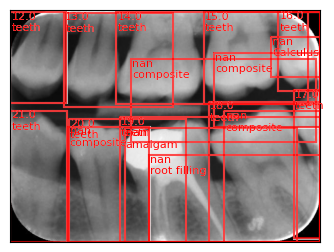

In [3]:
# List of image files
file_name_list = sorted(list(df[file_col].unique()))
print(f'Processing {len(file_name_list)} files.')

df_clipped_list = []

for f, file_name in enumerate(file_name_list):

    if (f + 1) % 200 == 0:
        print(f'Loading file {f + 1} of {len(file_name_list)}')

    df_file = df.loc[df[file_col] == file_name]
    file = os.path.join(image_dir, file_name)
    
    if is_image(file):
    
        im = ImageData().load_image(file)

        pos_list = df_file[pos_col].tolist()
        disease_list = df_file[disease_col].tolist()        
        
        im_height = im.shape[0]
        im_width = im.shape[1]
        
        bboxes = df_file[bbox_col].tolist()
        bboxes_clipped = [clipxywh(list(bbox), xlim=(0, im_width), ylim=(0, im_height)) for bbox in bboxes]
        
        df_clipped = pd.DataFrame({bbox_col: bboxes_clipped, 
                                   pos_col: pos_list,
                                   disease_col: disease_list})
        
        df_clipped.insert(loc=0, column='file_name', value=file_name)
        df_clipped.insert(loc=1, column='width', value=im_width)
        df_clipped.insert(loc=2, column='height', value=im_height)

        df_clipped_list.append(df_clipped)

df_clipped = pd.concat(df_clipped_list, axis=0, ignore_index=True)

n_images = len(df_clipped['file_name'].unique())
print(f'Total number of images:      {n_images}')
print(f'Total number of annotations: {df_clipped.shape[0]}')

df_clipped.to_parquet(clipped_file)
print(f'Output file: {clipped_file}')

# Show the last image with the bounding boxes
labels = [f'{pos}\n{disease}' for pos, disease in zip(pos_list, disease_list)]
fig, ax = plt.subplots(figsize=(4, 4))
ax = plot_boxes(image=im, box_list=bboxes, label_list=labels, ax=ax, color='w')
ax = plot_boxes(image=im, box_list=bboxes_clipped, label_list=labels, ax=ax, color='r')
plt.show()

In [4]:
# Split data into Training, testing and validation
n_images_train = 800
n_images_test = 100
n_images_val = n_images - n_images_train - n_images_test

# Shuffle the list of images
seed = 123
shuffled_list = sorted(list(df_clipped['file_name'].unique()))
random.seed(seed)
random.shuffle(shuffled_list)

train_files = shuffled_list[:n_images_train]
test_files = shuffled_list[n_images_train: n_images_train + n_images_test]
val_files = shuffled_list[n_images_train + n_images_test:]

print(len(train_files))
print(len(test_files))
print(len(val_files))

# Let's make sure that there is no overlap between these files
print(set(train_files).intersection(test_files))
print(set(train_files).intersection(val_files))
print(set(test_files).intersection(val_files))

# Add the new data set label to the data frame
df_dset = df_clipped.copy().assign(dset=None)
df_dset.loc[df_dset['file_name'].isin(train_files), 'dset'] = 'train'
df_dset.loc[df_dset['file_name'].isin(test_files), 'dset'] = 'test'
df_dset.loc[df_dset['file_name'].isin(val_files), 'dset'] = 'val'

# Let's make sure that we have assigned all files
display(df_dset.loc[df_dset['dset'].isnull()])

df_dset.to_parquet(dset_file)
print(f'Output file {dset_file}')

800
100
93
set()
set()
set()


,file_name,width,height,bbox,pos,disease,dset


Output file /app/data_model/dataset_object_roboflow_240930/roboflow_240930_dset.parquet


In [5]:
display(df_dset.head(2))

,file_name,width,height,bbox,pos,disease,dset
0,0018429fa9.jpg,640,480,"[56, 348, 84, 132]",NaN,composite,test
1,0018429fa9.jpg,640,480,"[0, 2, 145, 270]",2.0,teeth,test


### Histograms ###

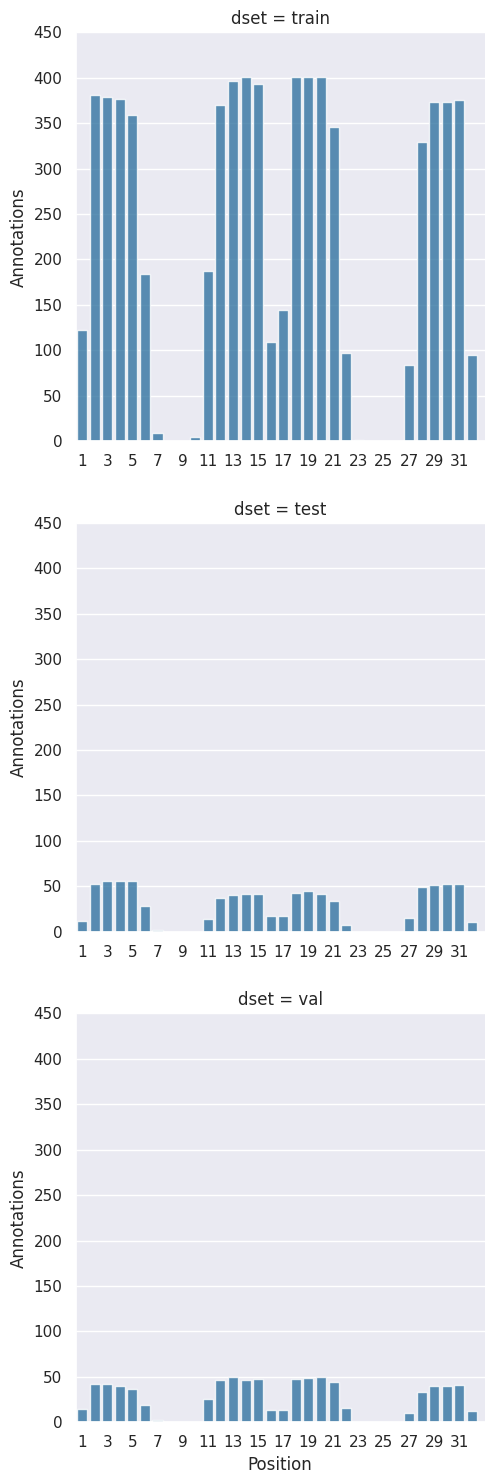

In [49]:
label_col = 'pos'
dset_col = 'dset'
dset_order = ['train', 'test', 'val']
label_list = np.arange(1, 33)

dfh = df_dset.loc[df_dset[label_col].isin(label_list)].\
                astype({label_col: int})

# Count the number of annotations for each label
annotations = dfh[[label_col, dset_col, 'file_name']].\
    groupby([label_col, dset_col]).\
    count().\
    reset_index(drop=False).\
    rename(columns={'file_name': 'n_annotations'}).\
    sort_values(by=[dset_col, label_col], ascending=True).\
    reset_index(drop=True)

annotations[dset_col] = pd.Categorical(annotations[dset_col], categories=dset_order, ordered=True)
annotations[pos_col] = pd.Categorical(annotations[pos_col], categories=label_list, ordered=True)
annotations = annotations.sort_values(by=[dset_col, pos_col], ascending=True)

sns.set_theme(style='darkgrid', palette='tab10')

g = sns.catplot(data=annotations, 
                kind='bar', 
                x=label_col, 
                y='n_annotations', 
                row=dset_col, 
                alpha=0.80, 
                height=5)

g.set_axis_labels(x_var='Position', y_var='Annotations')
g.set_titles(col_template='{col_name}')


# Loop through each axis and show y-axis tick labels
for ax in g.axes.flat:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.set(yticks=np.arange(0, 500, 50))
    ax.set(xticks=np.arange(0, 34, 2))

plt.subplots_adjust(hspace=0.2) # Increase hspace for more vertical space

# Save the plot
plot_name = 'roboflow_annotations.png'
plot_file = os.path.join(image_dir, plot_name)
plt.savefig(plot_file, bbox_inches='tight')

plt.show()

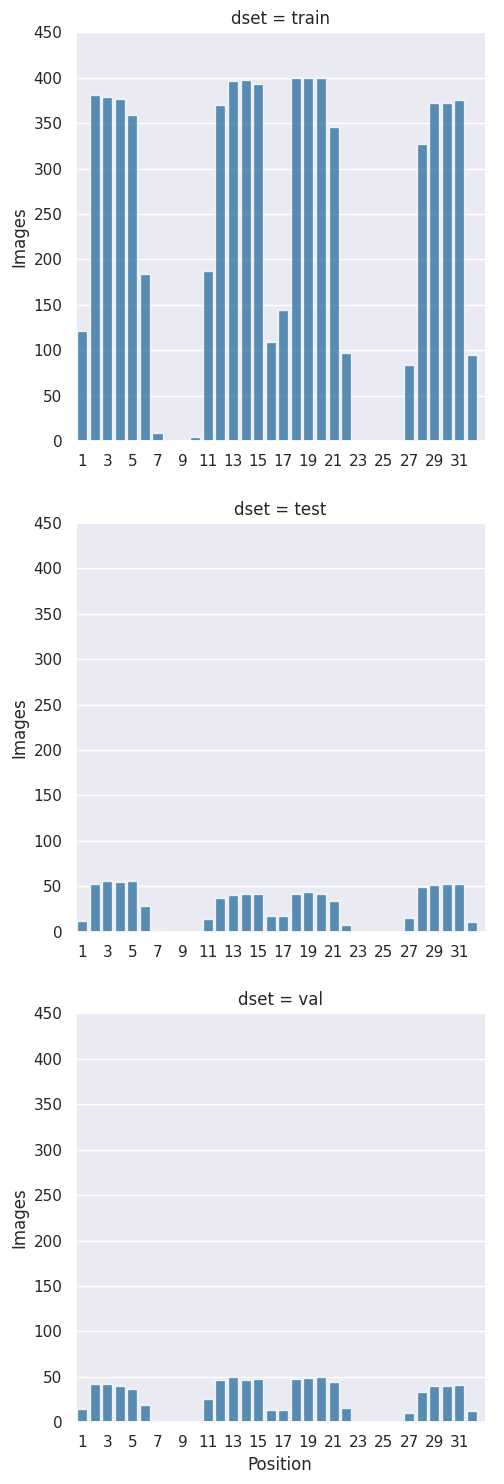

In [50]:
label_col = 'pos'
dset_col = 'dset'
dset_order = ['train', 'test', 'val']
label_list = np.arange(1, 33)

dfh = df_dset.loc[df_dset[label_col].isin(label_list)].\
                astype({label_col: int})

# Count the number of annotations for each label
annotations = dfh[[label_col, dset_col, 'file_name']].\
    groupby([label_col, dset_col]).\
    nunique().\
    reset_index(drop=False).\
    rename(columns={'file_name': 'n_images'}).\
    sort_values(by=[dset_col, label_col], ascending=True).\
    reset_index(drop=True)

annotations[dset_col] = pd.Categorical(annotations[dset_col], categories=dset_order, ordered=True)
annotations[pos_col] = pd.Categorical(annotations[pos_col], categories=label_list, ordered=True)
annotations = annotations.sort_values(by=[dset_col, pos_col], ascending=True)

sns.set_theme(style='darkgrid', palette='tab10')

g = sns.catplot(data=annotations, 
                kind='bar', 
                x=label_col, 
                y='n_images', 
                row=dset_col, 
                alpha=0.80, 
                height=5)

g.set_axis_labels(x_var='Position', y_var='Images')
g.set_titles(col_template='{col_name}')

# Loop through each axis and show y-axis tick labels
for ax in g.axes.flat:
    ax.tick_params(labelleft=True, labelbottom=True)
    ax.set(yticks=np.arange(0, 500, 50))
    ax.set(xticks=np.arange(0, 34, 2))

plt.subplots_adjust(hspace=0.2) # Increase hspace for more vertical space

# Save the plot
plot_name = 'roboflow_annotations.png'
plot_file = os.path.join(image_dir, plot_name)
plt.savefig(plot_file, bbox_inches='tight')

plt.show()